In [ ]:
import pandas as pd
import numpy as np


In [ ]:


pd.set_option('display.max_rows', None)


In [ ]:
df=pd.read_csv("/content/gurgaon_properties_cleaned_v1.csv")

In [ ]:
df.head(2)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,not available,2.0,NaN,0 to 1 Year Old,"['Sector 55-56 Metro Station', 'The Leaf Mall ...",NaN,"['Lift(s)', 'Park']"
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,"study room,servant room",4.0,NaN,Within 6 months,"['Sant Soordas Sihi Metro Station', 'Airia Mal...",NaN,"['Power Back-up', 'Intercom Facility', 'Lift(s..."


In [ ]:
df[['area','areaWithType']].head(5)

,area,areaWithType
0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...
1,1105.0,Carpet area: 1103 (102.47 sq.m.)
2,58228.0,Carpet area: 58141 (5401.48 sq.m.)
3,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...
4,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...


In [ ]:
df.iloc[0]["areaWithType"]
pd.set_option('display.max_columns', None)

In [ ]:
# new=df['areaWithType'][df["areaWithType"].str.contains("Super")]
# df["Super_area"]=new.str.split('(').str[0].str.extract(r'(\d+)')
# df["Super_area"].fillna(0,inplace=True)
import re


In [ ]:
def get_bult_up_area(text):
  match=re.search(r"Super Built up area (\d+\.?\d*)",text)
  if match:
    return float(match.group(1))
  return None
df["super_built"]=df["areaWithType"].apply(get_bult_up_area)

In [ ]:
df["areaWithType"].head(20)

,areaWithType
0,Super Built up area 1081(100.43 sq.m.)Carpet a...
1,Carpet area: 1103 (102.47 sq.m.)
2,Carpet area: 58141 (5401.48 sq.m.)
3,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...
4,Super Built up area 1995(185.34 sq.m.)Built Up...
5,Super Built up area 632(58.71 sq.m.)Carpet are...
6,Super Built up area 5350(497.03 sq.m.)
7,Super Built up area 2338(217.21 sq.m.)
8,Super Built up area 1889(175.49 sq.m.)
9,Plot area 1185.51(110.14 sq.m.)


In [ ]:
def extract_built(text):
  match=re.search(r'Built\s*Up\s*area[: ]\s*(\d+\.?\d*)',text)
  if match:
    return float(match.group(1))
  else:
    return None


In [ ]:
df["buld_area"]=df["areaWithType"].apply(extract_built)


In [ ]:
df["carpet_area"]=df["areaWithType"].str.extract(r"Carpet area[: ]\s*(\d+\.?\d*)").astype("float")

In [ ]:
df["plot_area"]=df["areaWithType"].str.extract(r"Plot area\s*(\d+\.?\d*)").astype("float")


In [ ]:
print(df["buld_area"].isnull().sum())
df["plot_area"].isnull().sum()


2616


np.int64(3121)

In [ ]:
# df["buld_area"][df["buld_area"].isnull()]=df["plot_area"][~df["plot_area"].isnull()]
df["buld_area"].fillna(df["plot_area"],inplace=True)

/tmp/ipykernel_696/655818454.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["buld_area"].fillna(df["plot_area"],inplace=True)


In [ ]:
print(df["buld_area"].isnull().sum())

2059


In [ ]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['buld_area']):
        return row['buld_area']
    else:
        if round(row['area']/row['buld_area']) == 9.0:
            return row['buld_area'] * 9
        elif round(row['area']/row['buld_area']) == 11.0:
            return row['buld_area'] * 10.7
        else:
          return row['buld_area']

In [ ]:
df["buld_area"]=df.apply(convert_scale,axis=1)
df.drop(columns="plot_area",inplace=True)

In [ ]:
df.head(20)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built,buld_area,carpet_area
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,not available,2.0,NaN,0 to 1 Year Old,"['Sector 55-56 Metro Station', 'The Leaf Mall ...",NaN,"['Lift(s)', 'Park']",1081.0,NaN,650.0
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,"study room,servant room",4.0,NaN,Within 6 months,"['Sant Soordas Sihi Metro Station', 'Airia Mal...",NaN,"['Power Back-up', 'Intercom Facility', 'Lift(s...",NaN,NaN,1103.0
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,not available,0.0,NaN,Under Construction,"['V3S Sapphire Ninety Mall', 'Sector 86 Road',...",[],"['Intercom Facility', 'Lift(s)', 'Park']",NaN,NaN,58141.0
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2,2,1,not available,17.0,NaN,0 to 1 Year Old,"['Huda City Centre', 'Omaxe City Centre', 'Nin...",[],"['Feng Shui / Vaastu Compliant', 'Security / F...",NaN,1000.00,585.0
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,"servant room,others",10.0,North-West,1 to 5 Year Old,"['Sapphire 93 Mall', 'Dwarka Expressway', 'NH-...","['3 Wardrobe', '6 Fan', '1 Exhaust Fan', '3 Ge...","['Centrally Air Conditioned', 'Water purifier'...",1995.0,1615.00,1476.0
5,flat,suncity avenue,sector 102,0.48,9022.0,532.0,Super Built up area 632(58.71 sq.m.)Carpet are...,2,2,1,store room,5.0,North-East,1 to 5 Year Old,"['The Hive', 'JMS Marine Square', 'Gurugram Rd...","['3 Fan', '10 Light', 'No AC', 'No Bed', 'No C...","['Centrally Air Conditioned', 'Water purifier'...",632.0,NaN,532.0
6,flat,paras quartier,gwal pahari,7.50,14018.0,5350.0,Super Built up area 5350(497.03 sq.m.),4,4,3+,"pooja room,servant room,others",20.0,North-East,0 to 1 Year Old,"['Sector 55-56 Metro Station', 'Ambience Mall'...","['4 Wardrobe', '3 Fan', '1 Geyser', '1 Microwa...","['Feng Shui / Vaastu Compliant', 'Security / F...",5350.0,NaN,NaN
7,flat,experion the heartsong,sector 108,2.00,8554.0,2338.0,Super Built up area 2338(217.21 sq.m.),3,3,3+,servant room,14.0,East,1 to 5 Year Old,"['Galleria 108 Mall', 'Dwarka Expressway', 'Ce...","['5 AC', 'No Bed', 'No Chimney', 'No Curtains'...","['Security / Fire Alarm', 'Feng Shui / Vaastu ...",2338.0,NaN,NaN
8,flat,adani m2k oyster grande,sector 102,1.90,9105.0,2087.0,Super Built up area 1889(175.49 sq.m.),3,4,3,servant room,8.0,North-East,1 to 5 Year Old,"['WTC Plaza', 'Star Mall', 'Dwarka Expy, Dhanw...","['7 Fan', '4 Geyser', '6 Light', '5 AC', 'No B...","['Water purifier', 'Security / Fire Alarm', 'F...",1889.0,NaN,NaN
9,house,independent,sector 105,1.20,10122.0,1186.0,Plot area 1185.51(110.14 sq.m.),6,2,1,not available,2.0,North-West,10+ Year Old,"['Palam Vihar Vyapar kendra', 'Chintapurni Man...",NaN,"['Private Garden / Terrace', 'Waste Disposal']",NaN,1185.51,NaN


In [ ]:
new_cols=['others', 'pooja room', 'servant room', 'store room', 'study room']
for cols in new_cols:
 df[cols]=df["additionalRoom"].str.contains(cols).astype(int)

In [ ]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built,buld_area,carpet_area,others,pooja room,servant room,store room,study room
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,not available,2.0,NaN,0 to 1 Year Old,"['Sector 55-56 Metro Station', 'The Leaf Mall ...",NaN,"['Lift(s)', 'Park']",1081.0,NaN,650.0,0,0,0,0,0
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,"study room,servant room",4.0,NaN,Within 6 months,"['Sant Soordas Sihi Metro Station', 'Airia Mal...",NaN,"['Power Back-up', 'Intercom Facility', 'Lift(s...",NaN,NaN,1103.0,0,0,1,0,1
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,not available,0.0,NaN,Under Construction,"['V3S Sapphire Ninety Mall', 'Sector 86 Road',...",[],"['Intercom Facility', 'Lift(s)', 'Park']",NaN,NaN,58141.0,0,0,0,0,0
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2,2,1,not available,17.0,NaN,0 to 1 Year Old,"['Huda City Centre', 'Omaxe City Centre', 'Nin...",[],"['Feng Shui / Vaastu Compliant', 'Security / F...",NaN,1000.0,585.0,0,0,0,0,0
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,"servant room,others",10.0,North-West,1 to 5 Year Old,"['Sapphire 93 Mall', 'Dwarka Expressway', 'NH-...","['3 Wardrobe', '6 Fan', '1 Exhaust Fan', '3 Ge...","['Centrally Air Conditioned', 'Water purifier'...",1995.0,1615.0,1476.0,1,0,1,0,0


In [ ]:
from datetime import datetime


In [ ]:

def categorize_age__possession(data):

  if pd.isna(data):
    return "Undefined"
  if "0 to 1 Year Old" in data or "Within 6 months" in data or "Within 3 months":
    return "New Property"
  if "1 to 5 Year Old" in data:
    return "Relatively New"
  if "5 to 10 Year Old" in data:
    return "Moderately old"
  if "10+ Year Old" in data:
    return "Old"
  if "Under Construction" or "By" in data:
    return "Under construction"
  try:
    date=datetime.strptime(data.strip(),"%b %Y")
    today = datetime.today()
    if date>today:
      return "Under construction"
    else:
      return "Ready to move"
  except:
    return "Undefined"


In [ ]:
df["agePossession"]=df["agePossession"].apply(categorize_age__possession)

In [ ]:
df.shape

(3803, 25)

In [ ]:
new_df=df[df["furnishDetails"].notnull()]
len(new_df['furnishDetails'][new_df["furnishDetails"].str.contains(r"\s?[[]]")])

/usr/local/lib/python3.12/dist-packages/pandas/core/strings/accessor.py:1327: FutureWarning: Possible nested set at position 4
  if regex and re.compile(pat).groups:


421

In [ ]:
df["new"]=pd.Series(df["furnishDetails"].value_counts().index.tolist())

In [ ]:
import ast
df["new"].fillna("[]",inplace=True)

df["new"] = df["new"].apply(ast.literal_eval)
df["new"].head(4)

/tmp/ipykernel_696/3749953346.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["new"].fillna("[]",inplace=True)


,new
0,[]
1,"[1 Light, No AC, No Bed, No Chimney, No Curtai..."
2,"[1 Modular Kitchen, No AC, No Bed, No Chimney,..."
3,"[1 Wardrobe, 1 Fan, 1 Light, No AC, No Bed, No..."


In [ ]:
whole=[]
for i in df["new"]:
  for j in i :
    whole.append(j)
whole

['1 Light',
 'No AC',
 'No Bed',
 'No Chimney',
 'No Curtains',
 'No Dining Table',
 'No Exhaust Fan',
 'No Fan',
 'No Geyser',
 'No Modular Kitchen',
 'No Microwave',
 'No Fridge',
 'No Sofa',
 'No Stove',
 'No TV',
 'No Wardrobe',
 'No Washing Machine',
 'No Water Purifier',
 '1 Modular Kitchen',
 'No AC',
 'No Bed',
 'No Chimney',
 'No Curtains',
 'No Dining Table',
 'No Exhaust Fan',
 'No Fan',
 'No Geyser',
 'No Light',
 'No Microwave',
 'No Fridge',
 'No Sofa',
 'No Stove',
 'No TV',
 'No Wardrobe',
 'No Washing Machine',
 'No Water Purifier',
 '1 Wardrobe',
 '1 Fan',
 '1 Light',
 'No AC',
 'No Bed',
 'No Chimney',
 'No Curtains',
 'No Dining Table',
 'No Exhaust Fan',
 'No Geyser',
 'No Modular Kitchen',
 'No Microwave',
 'No Fridge',
 'No Sofa',
 'No Stove',
 'No TV',
 'No Washing Machine',
 'No Water Purifier',
 '4 AC',
 'No Bed',
 'No Chimney',
 'No Curtains',
 'No Dining Table',
 'No Exhaust Fan',
 'No Fan',
 'No Geyser',
 'No Modular Kitchen',
 'No Light',
 'No Microwave',


In [ ]:
old=pd.Series(whole)

In [ ]:
new=[]
for i in whole:
  if i not in new:
    new.append(i)


In [ ]:
filter=pd.Series(new)
filter.head(5)

,0
0,1 Light
1,No AC
2,No Bed
3,No Chimney
4,No Curtains


In [ ]:
st=filter.str.extract(r"([A-Za-z\s]+)")


In [ ]:
new_filter=filter.str.replace("No","")

In [ ]:
containers=[]
contains=new_filter[new_filter.str.contains(r"\d+")].value_counts().index.str.extract(r"([A-Za-z\s]+)")
not_contains=new_filter[~new_filter.str.contains(r"\d+")].value_counts().index.str.extract(r"([A-Za-z\s]+)")


In [ ]:
for i in contains.values.tolist():
  for j in i:
   containers.append(j)

In [ ]:
for i in not_contains.values.tolist():
  for j in i:
   containers.append(j)

In [ ]:
new_contains=[]
for i in containers:
  if i not in new_contains:
    new_contains.append(i)

In [ ]:
df["furnishDetails"].fillna("[]",inplace=True)

/tmp/ipykernel_696/341919361.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["furnishDetails"].fillna("[]",inplace=True)


In [ ]:
df["furnishDetails"]=df["furnishDetails"].str.replace("No","0",)


In [ ]:
new_contains=pd.Series(new_contains).str.strip(' ').tolist()
new_contains

['Light',
 'Modular Kitchen',
 'Wardrobe',
 'Fan',
 'AC',
 'Geyser',
 'Chimney',
 'Stove',
 'Exhaust Fan',
 'Water Purifier',
 'Fridge',
 'Dining Table',
 'TV',
 'Curtains',
 'Bed',
 'Sofa',
 'Washing Machine',
 'Microwave']

In [ ]:
# # Extract Light
# light=df["furnishDetails"][df["furnishDetails"].str.contains("Light")]
# df["L"]=light.str.extract(r"(\d+)\s* Light").astype(int)


In [ ]:
# modular=df["furnishDetails"][df["furnishDetails"].str.contains("Modular Kitchen")]
# df["m"]=modular.str.extract(r"(\d+)\s* Modular Kitchen").astype(int)
# if df["furnishDetails"][df["furnishDetails"].str.contains("Modular Kitchen")].index.tolist()==modular.str.extract(r"(\d+)\s* Modular Kitchen").astype(int).index.tolist():
#     print(1)
# else:
#     print(0)

In [ ]:
# Wardrobe=df["furnishDetails"][df["furnishDetails"].str.contains("Wardrobe")]
# df["Modular"]=modular.str.extract(r"(\d+)\s* Wardrobe").astype(int)
# if df["furnishDetails"][df["furnishDetails"].str.contains("Wardrobe")].index.tolist()==modular.str.extract(r"(\d+)\s* Wardrobe").astype(int).index.tolist():
#     print(1)
# else:
#     print(0)

In [ ]:
for new in new_contains:
    i=df["furnishDetails"][df["furnishDetails"].str.contains(new)]
    df[new] = df["furnishDetails"].str.extract(rf"(\d+)\s*{new}").astype(float)




In [ ]:
new_contains

['Light',
 'Modular Kitchen',
 'Wardrobe',
 'Fan',
 'AC',
 'Geyser',
 'Chimney',
 'Stove',
 'Exhaust Fan',
 'Water Purifier',
 'Fridge',
 'Dining Table',
 'TV',
 'Curtains',
 'Bed',
 'Sofa',
 'Washing Machine',
 'Microwave']

In [ ]:
df["furnishDetails"].head(5)

,furnishDetails
0,[]
1,[]
2,[]
3,[]
4,"['3 Wardrobe', '6 Fan', '1 Exhaust Fan', '3 Ge..."


In [ ]:
df.head(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built,buld_area,carpet_area,others,pooja room,servant room,store room,study room,new,Light,Modular Kitchen,Wardrobe,Fan,AC,Geyser,Chimney,Stove,Exhaust Fan,Water Purifier,Fridge,Dining Table,TV,Curtains,Bed,Sofa,Washing Machine,Microwave
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,not available,2.0,NaN,New Property,"['Sector 55-56 Metro Station', 'The Leaf Mall ...",[],"['Lift(s)', 'Park']",1081.0,NaN,650.0,0,0,0,0,0,[],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,"study room,servant room",4.0,NaN,New Property,"['Sant Soordas Sihi Metro Station', 'Airia Mal...",[],"['Power Back-up', 'Intercom Facility', 'Lift(s...",NaN,NaN,1103.0,0,0,1,0,1,"[1 Light, No AC, No Bed, No Chimney, No Curtai...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,not available,0.0,NaN,New Property,"['V3S Sapphire Ninety Mall', 'Sector 86 Road',...",[],"['Intercom Facility', 'Lift(s)', 'Park']",NaN,NaN,58141.0,0,0,0,0,0,"[1 Modular Kitchen, No AC, No Bed, No Chimney,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2,2,1,not available,17.0,NaN,New Property,"['Huda City Centre', 'Omaxe City Centre', 'Nin...",[],"['Feng Shui / Vaastu Compliant', 'Security / F...",NaN,1000.0,585.0,0,0,0,0,0,"[1 Wardrobe, 1 Fan, 1 Light, No AC, No Bed, No...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,"servant room,others",10.0,North-West,New Property,"['Sapphire 93 Mall', 'Dwarka Expressway', 'NH-...","['3 Wardrobe', '6 Fan', '1 Exhaust Fan', '3 Ge...","['Centrally Air Conditioned', 'Water purifier'...",1995.0,1615.0,1476.0,1,0,1,0,0,"[4 AC, No Bed, No Chimney, No Curtains, No Din...",15.0,1.0,3.0,6.0,5.0,3.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0


In [ ]:
df[['Light',
 'Modular Kitchen',
 'Wardrobe',
 'Fan',
 'AC',
 'Geyser',
 'Chimney',
 'Stove',
 'Exhaust Fan',
 'Water Purifier',
 'Fridge',
 'Dining Table',
 'TV',
 'Curtains',
 'Bed',
 'Sofa',
 'Washing Machine',
 'Microwave']].fillna(0,inplace=True)

/tmp/ipykernel_696/2742309513.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  'Microwave']].fillna(0,inplace=True)


In [ ]:
new=df[['Light',
 'Modular Kitchen',
 'Wardrobe',
 'Fan',
 'AC',
 'Geyser',
 'Chimney',
 'Stove',
 'Exhaust Fan',
 'Water Purifier',
 'Fridge',
 'Dining Table',
 'TV',
 'Curtains',
 'Bed',
 'Sofa',
 'Washing Machine',
 'Microwave']]
new.fillna(0,inplace=True)

/tmp/ipykernel_696/1408190886.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new.fillna(0,inplace=True)


In [ ]:
from sklearn.cluster import KMeans,DBSCAN
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV


In [ ]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(new)
    wcss.append(kmeans.inertia_)

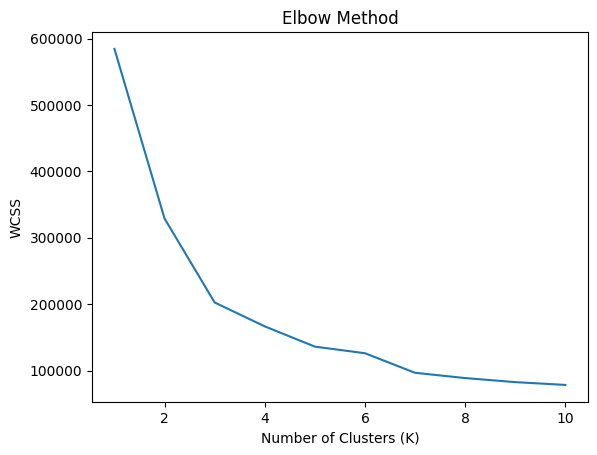

In [ ]:
plt.plot(range(1,11), wcss)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:

kmeans = KMeans()
param_grid = {
    'n_clusters': [2,3,4],
}
grid = GridSearchCV(kmeans, param_grid, cv=5)

grid.fit(new)
print(grid.best_params_)

{'n_clusters': 4}


In [ ]:
cols= ['Light','Modular Kitchen','Wardrobe','Fan','AC','Geyser','Chimney',
        'Stove','Exhaust Fan','Water Purifier','Fridge','Dining Table','TV',
        'Curtains','Bed','Sofa','Washing Machine','Microwave','furnishDetails']
for i in cols:
  df[i].fillna(0,inplace=True)




/tmp/ipykernel_696/1309707138.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(0,inplace=True)


In [ ]:
old=df[['Light','Modular Kitchen','Wardrobe','Fan','AC','Geyser','Chimney',
        'Stove','Exhaust Fan','Water Purifier','Fridge','Dining Table','TV',
        'Curtains','Bed','Sofa','Washing Machine','Microwave']]
old.isnull().sum()


,0
Light,0
Modular Kitchen,0
Wardrobe,0
Fan,0
AC,0
Geyser,0
Chimney,0
Stove,0
Exhaust Fan,0
Water Purifier,0


In [ ]:
n_cluster=3
kmeans=KMeans(n_clusters=3,random_state=42)
kmeans.fit(old)
kmeans.fit_predict(old)

array([1, 1, 1, ..., 1, 1, 2], dtype=int32)

In [ ]:
pd.Series(kmeans.fit_predict(old)).value_counts()

,count
1,2742
2,984
0,77


In [ ]:
df["Furnish_type"]=kmeans.fit_predict(old)


In [ ]:
df[["furnishDetails","Furnish_type"]][df['Furnish_type']==2].sample(10)

,furnishDetails,Furnish_type
441,"['3 Wardrobe', '8 Fan', '1 Exhaust Fan', '2 Ge...",2
1462,"['3 Wardrobe', '4 Fan', '1 Exhaust Fan', '11 L...",2
3696,"['6 Fan', '10 Light', '7 AC', '1 Chimney', '1 ...",2
2928,"['4 Wardrobe', '5 Fan', '1 Exhaust Fan', '4 Ge...",2
628,"['6 Wardrobe', '9 Fan', '6 Geyser', '17 Light'...",2
1061,"['6 Fan', '1 Fridge', '1 Exhaust Fan', '1 Dini...",2
3518,"['4 Wardrobe', '8 Fan', '1 Exhaust Fan', '4 Ge...",2
165,"['5 Fan', '1 Fridge', '1 Exhaust Fan', '3 Geys...",2
1756,"['1 Water Purifier', '17 Fan', '1 Fridge', '1 ...",2
2337,"['1 Water Purifier', '5 Fan', '1 Exhaust Fan',...",2


In [ ]:
df.head(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built,buld_area,carpet_area,others,pooja room,servant room,store room,study room,new,Light,Modular Kitchen,Wardrobe,Fan,AC,Geyser,Chimney,Stove,Exhaust Fan,Water Purifier,Fridge,Dining Table,TV,Curtains,Bed,Sofa,Washing Machine,Microwave,Furnish_type
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,not available,2.0,NaN,New Property,"['Sector 55-56 Metro Station', 'The Leaf Mall ...",[],"['Lift(s)', 'Park']",1081.0,NaN,650.0,0,0,0,0,0,[],0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,"study room,servant room",4.0,NaN,New Property,"['Sant Soordas Sihi Metro Station', 'Airia Mal...",[],"['Power Back-up', 'Intercom Facility', 'Lift(s...",NaN,NaN,1103.0,0,0,1,0,1,"[1 Light, No AC, No Bed, No Chimney, No Curtai...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,not available,0.0,NaN,New Property,"['V3S Sapphire Ninety Mall', 'Sector 86 Road',...",[],"['Intercom Facility', 'Lift(s)', 'Park']",NaN,NaN,58141.0,0,0,0,0,0,"[1 Modular Kitchen, No AC, No Bed, No Chimney,...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2,2,1,not available,17.0,NaN,New Property,"['Huda City Centre', 'Omaxe City Centre', 'Nin...",[],"['Feng Shui / Vaastu Compliant', 'Security / F...",NaN,1000.0,585.0,0,0,0,0,0,"[1 Wardrobe, 1 Fan, 1 Light, No AC, No Bed, No...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,"servant room,others",10.0,North-West,New Property,"['Sapphire 93 Mall', 'Dwarka Expressway', 'NH-...","['3 Wardrobe', '6 Fan', '1 Exhaust Fan', '3 Ge...","['Centrally Air Conditioned', 'Water purifier'...",1995.0,1615.0,1476.0,1,0,1,0,0,"[4 AC, No Bed, No Chimney, No Curtains, No Din...",15.0,1.0,3.0,6.0,5.0,3.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,2


In [ ]:
df["features"].fillna("[]",inplace=True)
extract=df["features"].apply(ast.literal_eval)
df["extract"]=pd.Series(extract.value_counts().index.tolist())

/tmp/ipykernel_696/2354242837.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["features"].fillna("[]",inplace=True)


In [ ]:
df["extract"].fillna("[]",inplace=True)

/tmp/ipykernel_696/683709124.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["extract"].fillna("[]",inplace=True)


In [ ]:
df["extract"]=pd.Series(df["features"].value_counts().index.tolist())
df["extract"].fillna("[]",inplace=True)

/tmp/ipykernel_696/1650959621.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["extract"].fillna("[]",inplace=True)


In [ ]:
df["extract"].fillna("[]",inplace=True)

df["extract"] = df["extract"].apply(ast.literal_eval)
df["extract"].sample(10)

,extract
2751,[]
949,"[Security / Fire Alarm, Feng Shui / Vaastu Com..."
1240,"[Security / Fire Alarm, Feng Shui / Vaastu Com..."
2051,[]
2867,[]
355,"[Security / Fire Alarm, Intercom Facility, Lif..."
2023,[]
2975,[]
367,"[Water purifier, Security / Fire Alarm, Feng S..."
2636,[]


In [ ]:
bag=[]
for i in df["extract"]:
  for j in i:
    bag.append(j)


In [ ]:
bucket=pd.Series(bag)

In [ ]:
extract_value=bucket.value_counts().index.tolist()

In [ ]:
extract_value
for i in extract_value:
  df[i]=df["features"].str.contains(i).astype(int)

/tmp/ipykernel_696/1424819011.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[i]=df["features"].str.contains(i).astype(int)


In [ ]:
amenity_rating = {
'Swimming Pool':5,
'Club house / Community Center':5,
'Fitness Centre / GYM':5,
'Private Garden / Terrace':5,
'Centrally Air Conditioned':5,
'Power Back-up':5,
'Low Density Society':5,

'Park':4,
'Visitor Parking':4,
'Lift(s)':4,
'Security Personnel':4,
'Security / Fire Alarm':4,
'Piped-gas':4,
'Water softening plant':4,
'Separate entry for servant room':4,

'Maintenance Staff':3,
'Intercom Facility':3,
'Rain Water Harvesting':3,
'Shopping Centre':3,
'Internet/wi-fi connectivity':3,
'Water purifier':3,

'Water Storage':2,
'Waste Disposal':2,
'Natural Light':2,
'Airy Rooms':2,
'Spacious Interiors':2,

'Feng Shui / Vaastu Compliant':1,
'High Ceiling Height':1,
'False Ceiling Lighting':1,
'Recently Renovated':1,
'No open drainage around':1,
'Bank Attached Property':1
}

In [ ]:
def rating(data):
  total=0
  for i,j in amenity_rating.items():
    if data[i]!=0:
      total+=j
  return total








In [ ]:
new_df=df[['Swimming Pool',
 'Club house / Community Center',
 'Fitness Centre / GYM',
 'Private Garden / Terrace',
 'Centrally Air Conditioned',
 'Power Back-up',
 'Low Density Society',
 'Park',
 'Visitor Parking',
 'Lift(s)',
 'Security Personnel',
 'Security / Fire Alarm',
 'Piped-gas',
 'Water softening plant',
 'Separate entry for servant room',
 'Maintenance Staff',
 'Intercom Facility',
 'Rain Water Harvesting',
 'Shopping Centre',
 'Internet/wi-fi connectivity',
 'Water purifier',
 'Water Storage',
 'Waste Disposal',
 'Natural Light',
 'Airy Rooms',
 'Spacious Interiors',
 'Feng Shui / Vaastu Compliant',
 'High Ceiling Height',
 'False Ceiling Lighting',
 'Recently Renovated',
 'No open drainage around',
 'Bank Attached Property']]

In [ ]:
df["rating"]=new_df.apply(rating,axis=1)
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built,buld_area,carpet_area,others,pooja room,servant room,store room,study room,new,Light,Modular Kitchen,Wardrobe,Fan,AC,Geyser,Chimney,Stove,Exhaust Fan,Water Purifier,Fridge,Dining Table,TV,Curtains,Bed,Sofa,Washing Machine,Microwave,Furnish_type,extract,Park,Maintenance Staff,Visitor Parking,Lift(s),Club house / Community Center,Fitness Centre / GYM,Water Storage,Swimming Pool,Rain Water Harvesting,Feng Shui / Vaastu Compliant,Intercom Facility,Security / Fire Alarm,Security Personnel,Shopping Centre,Waste Disposal,Natural Light,No open drainage around,Internet/wi-fi connectivity,Airy Rooms,High Ceiling Height,Piped-gas,Separate entry for servant room,Water softening plant,Low Density Society,Spacious Interiors,False Ceiling Lighting,Private Garden / Terrace,Power Back-up,Water purifier,Recently Renovated,Bank Attached Property,Centrally Air Conditioned,rating
3119,flat,signature global solera,sector 107,0.28,5674.0,493.0,Carpet area: 489 (45.43 sq.m.),2,2,2,not available,11.0,North,New Property,"['Gurgaon Dreamz Mall', 'Dwarka Expressway', ""...","['1 Wardrobe', '3 Fan', '5 Light', '0 AC', '0 ...","['Power Back-up', 'Lift(s)', 'Maintenance Staf...",NaN,NaN,489.00,0,0,0,0,0,[],5.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,[],1,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,21
1696,house,ss omnia,sector 86,0.42,84000.0,50.0,Plot area 50(4.65 sq.m.),5,3,2,not available,3.0,NaN,New Property,"['Orris Community Center', 'Essar Petrol Pump'...",[],[],NaN,50.0,NaN,0,0,0,0,0,"[2 Fan, 1 Geyser, 2 Light, 1 Chimney, 2 Wardro...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,"[Security / Fire Alarm, Lift(s), Water purifie...",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3082,flat,mapsko casa bella,sector 82,3.00,6134.0,4891.0,Super Built up area 4890(454.3 sq.m.),4,6,3+,"pooja room,servant room",25.0,West,New Property,"['Vatika City Centre Mall', 'Pataudi Road', 'B...","['1 Water Purifier', '12 Fan', '1 Exhaust Fan'...","['Security / Fire Alarm', 'Power Back-up', 'Fe...",4890.0,NaN,NaN,0,1,1,0,0,[],50.0,1.0,0.0,12.0,7.0,4.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0,[],1,1,1,0,1,1,1,1,1,1,1,1,1,1,0,1,1,0,1,0,0,0,0,0,1,1,0,1,0,1,0,0,60
489,flat,mapsko mount ville,sector 79,1.50,8264.0,1815.0,Super Built up area 1815(168.62 sq.m.)Carpet a...,3,4,3+,servant room,11.0,South,New Property,"['Huda Metro Station (Gurugram)', 'Sapphire 83...","['4 Wardrobe', '6 Fan', '1 Exhaust Fan', '3 Ge...","['Security / Fire Alarm', 'Power Back-up', 'Fe...",1815.0,NaN,1071.33,0,0,1,0,0,"[7 Fan, 7 Light, 1 Modular Kitchen, 1 Chimney,...",15.0,1.0,4.0,6.0,5.0,3.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2,"[Feng Shui / Vaastu Compliant, Private Garden ...",1,1,1,0,1,1,1,1,0,1,1,1,1,1,0,1,0,1,1,1,1,1,1,0,1,1,0,1,0,0,0,1,76
1450,house,independent,sector 3 phase 2,0.40,8000.0,500.0,Built Up area: 500 (46.45 sq.m.)Carpet area: 3...,2,1,0,not available,1.0,South,New Property,NaN,[],[],NaN,500.0,300.00,0,0,0,0,0,"[6 Wardrobe, 4 AC, 1 Modular Kitchen, 1 Chimne...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,"[Water purifier, Security / Fire Alarm, Power ...",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
new_ext=['Park',
 'Maintenance Staff',
 'Visitor Parking',
 'Lift(s)',
 'Club house / Community Center',
 'Fitness Centre / GYM',
 'Water Storage',
 'Swimming Pool',
 'Rain Water Harvesting',
 'Feng Shui / Vaastu Compliant',
 'Intercom Facility',
 'Security / Fire Alarm',
 'Security Personnel',
 'Shopping Centre',
 'Waste Disposal',
 'Natural Light',
 'No open drainage around',
 'Internet/wi-fi connectivity',
 'Airy Rooms',
 'High Ceiling Height',
 'Piped-gas',
 'Separate entry for servant room',
 'Water softening plant',
 'Low Density Society',
 'Spacious Interiors',
 'False Ceiling Lighting',
 'Private Garden / Terrace',
 'Power Back-up',
 'Water purifier',
 'Recently Renovated',
 'Bank Attached Property',
 'Centrally Air Conditioned',"rating"]

In [ ]:
df["nearbyLocations"].sample(10)

,count
nearbyLocations,
"['Sapphire 83 Mall', 'Dwarka Expressway', 'Central Peripheral Road', 'NH 08', 'Pataudi Road', 'Delhi Public School Sector 84', 'DPG Institute of Technology', 'Genesis Hospital Sector 84', 'Indira Gandhi International Airport', 'Imt Manesar', 'Holiday Inn Hotel Sector 90', 'SkyJumper Trampoline Park', 'Nakhrola Stadium Sector 81A']",73
"['Airia Mall Sector 68', 'Southern Peripheral Road', 'Golf Course Extension Rd', 'Imperio School', 'DPG Institute of Technology', 'Ektaa Hospitals', 'Indira Gandhi International Airport', 'Vipul Trade Business Centre', 'Radisson Hotel Gurugram', 'SkyJumper Trampoline Park']",73
"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. Sarkar Clinic', 'Sagar Clinic', 'Vijay Petrol Pump', 'HP Petrol Pump', 'Essar Petrol Pump', 'Indian Oil']",41
"['Khan Market', 'The Esplanade Mall', 'Dwarka Expressway', 'Garhi Road', 'Delhi Public School', 'SGT University', 'Aryan Hospital', 'Indira Gandhi Int. Airport', 'Basai Dhankot', 'The Executive Centre', 'Inde Hotels & Resorts', 'Appu Ghar', 'DLF Golf and Country Club']",39
"['Sector 55-56 metro', 'Global city centre', 'Sohna road dhunela', 'Gd goenka university', 'Maharana pratap school', 'Vardaan hospital and trauma centre', 'Indira Gandhi International Airport', 'Garhi harsaru railway station Gurgaon']",37
"['Airia Mall', 'Golf Course Extn Road', 'Sohna Road', 'Southern Peripheral Rd, Gurugram', 'Kunskapsskolan International', 'Ektaa Hospitals Main Sohna Rd', 'Sanjeevani Hospital - Child Specialist', 'Federal Bank Sector 71', 'Central Bank Of India Sohna Rd', 'Axis Bank, Sohna Rd', 'Spaze Palazo, Golf Course Ext Rd', 'VATIKA BUSINESS PARK Sohna Rd', 'The Medicity, Spaze iTech Park', 'Tulip Violet Society, Sector 69', 'IndianOil, Hasanpur']",35
"['Sant Soordas Sihi Metro Station', 'Airia Mall', 'Dwarka Expressway', 'Pataudi Road', 'NH-8', 'KMP Expressway', 'RPS International School', 'Genesis Hospital Sector 84', 'Gurgaon Railway Station', 'Vatika Business Park Sector 49', 'Holiday Inn Gurugram Sector 90', 'De Adventure Amusement Park', 'National Tennis Academy Sector 98', 'IMT Manesar']",33
"['WorldMark Gurgaon', 'Sohna Road', 'Golf Course Road', 'CK Birla Hospital', 'Delhi International Airport', 'Lemon Tree Hotel']",32
"['Huda Metro Station (Gurugram)', 'Vatika Town Square-INXT', 'Manesar Road', 'NH 48', 'Euro International School, Sec 84', 'SGT University', 'Miracles Apollo Cradle Hospital', 'Indira Gandhi Intl Airport', 'Garhi Harsaru Junction']",31
